# FLEXIMOD market result quick analysis

Small notebook for checking market electricity procurement and market cost/revenue components.

Expected result files in `RESULTS_DIR`:

- `market_ledger.csv` preferred for market positions and settlement values
- `dispatch_results.csv` used as fallback
- `summary_indicators.csv` optional


In [126]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Change this to the output folder of the case you want to analyse.
RESULTS_DIR = Path("../data/output/steel_plant_DE_steel_cost_minimization")

RESULTS_DIR.resolve()

WindowsPath('C:/Users/khm/Models/FLEXIMOD/data/output/steel_plant_DE_steel_cost_minimization')

In [127]:
def read_optional_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path.name}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    print(f"Loaded {path.name}: {len(df):,} rows, {len(df.columns):,} columns")
    return df


market = read_optional_csv(RESULTS_DIR / "market_ledger.csv")
dispatch = read_optional_csv(RESULTS_DIR / "dispatch_results.csv")
summary = read_optional_csv(RESULTS_DIR / "summary_indicators.csv")

market.head() if not market.empty else dispatch.head()

Missing: market_ledger.csv
Missing: dispatch_results.csv
Missing: summary_indicators.csv


""


In [128]:
def numeric_series(df: pd.DataFrame, column: str, default: float = 0.0) -> pd.Series:
    if df.empty or column not in df.columns:
        return pd.Series([default], dtype=float)
    return pd.to_numeric(df[column], errors="coerce").fillna(default)


def column_sum(df: pd.DataFrame, column: str) -> float:
    return float(numeric_series(df, column).sum())


def first_existing(df: pd.DataFrame, columns: list[str]) -> str | None:
    for column in columns:
        if not df.empty and column in df.columns:
            return column
    return None


def weighted_value(df: pd.DataFrame, quantity_col: str, price_col: str) -> float:
    if df.empty or quantity_col not in df.columns or price_col not in df.columns:
        return 0.0
    quantity = pd.to_numeric(df[quantity_col], errors="coerce").fillna(0.0)
    price = pd.to_numeric(df[price_col], errors="coerce").fillna(0.0)
    return float((quantity * price).sum())

## Electricity procurement by market

This plot answers: how much electricity came from day-ahead, intraday buy/sell, and activated aFRR down energy?

In [129]:
source = market if not market.empty else dispatch

procurement = {
    "Day-ahead procurement": column_sum(
        source,
        first_existing(source, ["day_ahead_position_MWh_el", "DA_position_MWh"]) or "",
    ),
    "Intraday buy": column_sum(
        source,
        first_existing(source, ["intraday_buy_MWh_el", "IDC_buy_MWh"]) or "",
    ),
    "Intraday sell": -column_sum(
        source,
        first_existing(source, ["intraday_sell_MWh_el", "IDC_sell_MWh"]) or "",
    ),
    "aFRR activated energy": column_sum(
        source,
        first_existing(source, ["afrr_energy_activated_MWh_el", "afrr_energy_activated_MWh"]) or "",
    ),
}

procurement_df = pd.DataFrame(
    {"market": procurement.keys(), "electricity_MWh": procurement.values()}
).query("electricity_MWh != 0")

display(procurement_df)

if procurement_df.empty:
    print("No electricity procurement or aFRR activation is recorded in these results.")
else:
    ax = procurement_df.plot.bar(
        x="market",
        y="electricity_MWh",
        legend=False,
        color=["#4C78A8", "#72B7B2", "#F58518", "#B279A2"][: len(procurement_df)],
        figsize=(8, 4),
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Electricity [MWh_el]")
    ax.set_xlabel("")
    ax.set_title("Electricity procurement by market")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

,market,electricity_MWh


No electricity procurement or aFRR activation is recorded in these results.


## Market cost / revenue waterfall

Positive bars increase cost. Negative bars are revenues or sales that reduce net market cost.

The waterfall focuses on market-facing electricity settlement, not material input costs such as iron ore or lime.

,component,value_EUR
0,Net market cost,0.0


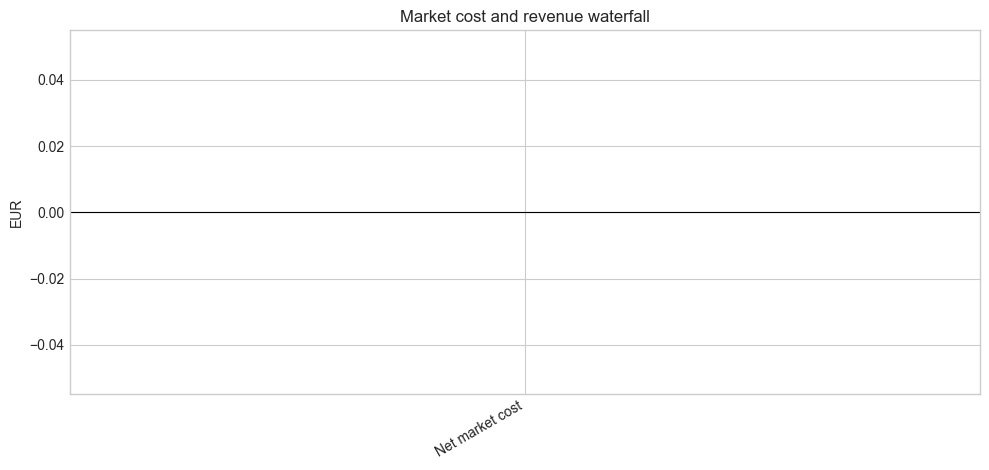

In [130]:
if not market.empty:
    components = {
        "Day-ahead electricity": weighted_value(
            market,
            "day_ahead_position_MWh_el",
            "day_ahead_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday buy": weighted_value(
            market,
            "intraday_buy_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday sell": -weighted_value(
            market,
            "intraday_sell_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR energy settlement": weighted_value(
            market,
            "afrr_energy_activated_MWh_el",
            "afrr_energy_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR capacity revenue": -column_sum(market, "afrr_capacity_revenue_EUR"),
    }
else:
    components = {
        "Electricity market cost": column_sum(dispatch, "electricity_market_cost_EUR"),
        "Additional electricity charges": column_sum(
            dispatch, "additional_electricity_charges_cost_EUR"
        ),
        "aFRR capacity revenue": -column_sum(dispatch, "afrr_capacity_revenue_EUR"),
    }

waterfall_df = pd.DataFrame(
    {"component": components.keys(), "value_EUR": components.values()}
).query("value_EUR != 0")
waterfall_df.loc[len(waterfall_df)] = ["Net market cost", waterfall_df["value_EUR"].sum()]

display(waterfall_df)

running = waterfall_df["value_EUR"].iloc[:-1].cumsum().shift(fill_value=0.0)
values = waterfall_df["value_EUR"].iloc[:-1]
labels = waterfall_df["component"].iloc[:-1].tolist()
net = waterfall_df["value_EUR"].iloc[-1]

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ["#D95F02" if value >= 0 else "#1B9E77" for value in values]
ax.bar(labels, values, bottom=running, color=colors)
ax.bar(["Net market cost"], [net], color="#4C78A8")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("EUR")
ax.set_title("Market cost and revenue waterfall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Optional: per-plant market procurement

Useful when the output contains several plants/routes.

In [131]:
if not market.empty and "plant_name" in market.columns:
    per_plant = market.groupby("plant_name", dropna=False).agg(
        day_ahead_MWh=("day_ahead_position_MWh_el", "sum"),
        afrr_activated_MWh=("afrr_energy_activated_MWh_el", "sum"),
        capacity_revenue_EUR=("afrr_capacity_revenue_EUR", "sum"),
    )
    display(per_plant)
    per_plant[["day_ahead_MWh", "afrr_activated_MWh"]].plot.bar(
        stacked=True,
        figsize=(10, 4),
        color=["#4C78A8", "#B279A2"],
    )
    plt.ylabel("Electricity [MWh_el]")
    plt.title("Electricity procurement by plant")
    plt.tight_layout()
else:
    print("No market_ledger.csv with plant_name column available.")

No market_ledger.csv with plant_name column available.


## Net cost by plant

Scans every use-case output folder under `data/output`, calculates net cost for every plant, and adds a portfolio total. It uses the most complete available output: net operating cost including grid fees, net operating cost, total net operating cost, or total variable cost.

In [132]:
def summary_value(row: pd.Series, column: str) -> float | None:
    value = pd.to_numeric(pd.Series([row.get(column)]), errors="coerce").iloc[0]
    return None if pd.isna(value) else float(value)


def net_cost_from_summary(summary: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in summary.iterrows():
        plant_name = row.get("plant_name", "unnamed plant")
        gross_cost = summary_value(row, "gross_operating_cost_EUR")
        variable_cost = summary_value(row, "total_variable_cost_EUR")
        net_incl_grid_fees = summary_value(
            row, "net_operating_cost_incl_grid_fees_EUR"
        )
        net_cost = summary_value(row, "net_operating_cost_EUR")
        total_net_cost = summary_value(row, "total_net_operating_cost_EUR")

        # Steel cost-minimisation has no market settlement columns: its
        # total_variable_cost_EUR is the complete process cost. Do not use
        # the zero-filled net-operating-cost placeholder in that case.
        if gross_cost is not None and abs(gross_cost) > 1e-9:
            if net_incl_grid_fees is not None:
                cost, basis = net_incl_grid_fees, "net operating cost incl. grid fees"
            elif net_cost is not None:
                cost, basis = net_cost, "net operating cost"
            else:
                cost, basis = gross_cost, "gross operating cost"
        elif total_net_cost is not None:
            cost, basis = total_net_cost, "total net operating cost"
        elif variable_cost is not None:
            cost, basis = variable_cost, "total variable cost"
        else:
            print(f"Skipping {plant_name}: no recognised cost column in summary_indicators.csv.")
            continue

        records.append({"plant_name": plant_name, "net_cost_EUR": cost, "cost_basis": basis})
    return pd.DataFrame(records)


OUTPUT_ROOT = RESULTS_DIR.parent.resolve()
summary_paths = sorted(OUTPUT_ROOT.glob("*/summary_indicators.csv"))

if not summary_paths:
    print(f"No summary_indicators.csv files found under {OUTPUT_ROOT}.")
else:
    cost_frames = []
    for summary_path in summary_paths:
        case_summary = pd.read_csv(summary_path)
        if "plant_name" not in case_summary.columns:
            print(f"Skipping {summary_path.parent.name}: no plant_name column.")
            continue

        case_costs = net_cost_from_summary(case_summary)
        if case_costs.empty:
            print(f"Skipping {summary_path.parent.name}: no recognised cost values.")
            continue

        case_costs.insert(0, "output_folder", summary_path.parent.name)
        cost_frames.append(case_costs)

    if not cost_frames:
        print("No recognised net-cost values were found in the output folders.")
    else:
        net_cost_by_plant = pd.concat(cost_frames, ignore_index=True)
        portfolio_total = net_cost_by_plant["net_cost_EUR"].sum()
        net_cost_by_plant.loc[len(net_cost_by_plant)] = {
            "output_folder": "All output folders",
            "plant_name": "All plants",
            "net_cost_EUR": portfolio_total,
            "cost_basis": "portfolio total",
        }
        net_cost_by_plant["net_cost_MEUR"] = net_cost_by_plant["net_cost_EUR"] / 1_000_000
        net_cost_by_plant["net_cost_BEUR"] = net_cost_by_plant["net_cost_EUR"] / 1_000_000_000
        display(
            net_cost_by_plant.style.format(
                {
                    "net_cost_EUR": "{:,.2f}",
                    "net_cost_MEUR": "{:,.2f}",
                    "net_cost_BEUR": "{:,.3f}",
                }
            )
        )


,output_folder,plant_name,net_cost_EUR,cost_basis,net_cost_MEUR,net_cost_BEUR
0,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120423_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"553,863,888.60",total variable cost,553.86,0.554
1,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120426_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"1,507,443,422.72",total variable cost,"1,507.44",1.507
2,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120421_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"3,837,337,556.90",total variable cost,"3,837.34",3.837
3,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120422_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"1,790,749,809.64",total variable cost,"1,790.75",1.791
4,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120427_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"389,017,656.80",total variable cost,389.02,0.389
5,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120432_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"1,061,531,933.26",total variable cost,"1,061.53",1.062
6,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120425_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"875,289,727.85",total variable cost,875.29,0.875
7,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120428_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"486,272,071.06",total variable cost,486.27,0.486
8,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120424_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"2,217,128,368.86",total variable cost,"2,217.13",2.217
9,fokusH2_2030_bf_bof_hybrid_hydrogen_natural_gas_external_steel_cost_minimization,P100000120423_bf_bof_hybrid_hydrogen_natural_gas_external,"629,965,896.92",total variable cost,629.97,0.630
